In [52]:
import numpy as np
import pandas as pd
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem.porter import PorterStemmer
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score
from sklearn.metrics import confusion_matrix, classification_report

In [53]:
import matplotlib.pyplot as plt
import seaborn as sns
print("Libraries imported successfully!")

Libraries imported successfully!


In [54]:
df = pd.read_csv("Restaurant_Reviews.tsv", delimiter="\t", quoting=3)
print("Dataset loaded successfully!")

Dataset loaded successfully!


In [55]:
import os

file_path = "Restaurant_Reviews.tsv"

# Check if the file already exists, if not, create a dummy file
if not os.path.exists(file_path):
    dummy_data = {
        'Review': [
            'I love this place!',
            'Terrible food and service.',
            'Great atmosphere and delicious dishes.',
            'Never coming back here again.',
            'Highly recommend the pasta!'
        ],
        'Liked': [1, 0, 1, 0, 1]
    }
    dummy_df = pd.DataFrame(dummy_data)
    dummy_df.to_csv(file_path, sep='\t', index=False, quoting=3)
    print(f"Dummy file '{file_path}' created.")
else:
    print(f"File '{file_path}' already exists.")


File 'Restaurant_Reviews.tsv' already exists.


In [56]:
df = pd.read_csv("Restaurant_Reviews.tsv", delimiter="\t", quoting=3)
print("Dataset loaded successfully!")


Dataset loaded successfully!


In [57]:
print(df.head())
print(df.info())

                                   Review  Liked
0                      I love this place!      1
1              Terrible food and service.      0
2  Great atmosphere and delicious dishes.      1
3           Never coming back here again.      0
4             Highly recommend the pasta!      1
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Review  5 non-null      object
 1   Liked   5 non-null      int64 
dtypes: int64(1), object(1)
memory usage: 212.0+ bytes
None


In [58]:
print("First 5 rows:")
print(df.head())
print("\nDataset Shape:", df.shape)
print("\nColumn Names:", df.columns)
print("\nDataset Information:")
df.info()
print("\nSentiment Distribution:")
print(df["Liked"].value_counts())

First 5 rows:
                                   Review  Liked
0                      I love this place!      1
1              Terrible food and service.      0
2  Great atmosphere and delicious dishes.      1
3           Never coming back here again.      0
4             Highly recommend the pasta!      1

Dataset Shape: (5, 2)

Column Names: Index(['Review', 'Liked'], dtype='object')

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Review  5 non-null      object
 1   Liked   5 non-null      int64 
dtypes: int64(1), object(1)
memory usage: 212.0+ bytes

Sentiment Distribution:
Liked
1    3
0    2
Name: count, dtype: int64


In [59]:
nltk.download('stopwords')

corpus = []
for i in range(len(df)):
    review = re.sub('[^a-zA-Z]', ' ', df['Review'][i])
    review = review.lower()
    review = review.split()
    ps = PorterStemmer()
    all_stopwords = stopwords.words('english')
    all_stopwords.remove('not') # 'not' is important for sentiment analysis
    review = [ps.stem(word) for word in review if not word in set(all_stopwords)]
    review = ' '.join(review)
    corpus.append(review)

print("Text preprocessing complete. Here are the first 5 processed reviews:")
for i, processed_review in enumerate(corpus[:5]):
    print(f"Original: {df['Review'][i]} -> Processed: {processed_review}")

Text preprocessing complete. Here are the first 5 processed reviews:
Original: I love this place! -> Processed: love place
Original: Terrible food and service. -> Processed: terribl food servic
Original: Great atmosphere and delicious dishes. -> Processed: great atmospher delici dish
Original: Never coming back here again. -> Processed: never come back
Original: Highly recommend the pasta! -> Processed: highli recommend pasta


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [60]:
cv = CountVectorizer(max_features=1500)
X = cv.fit_transform(corpus).toarray()
y = df.iloc[:, -1].values

print("Bag-of-Words model created. Shape of X (features):", X.shape)
print("Shape of y (labels):", y.shape)
print("First 5 feature vectors:\n", X[:5])
print("First 5 labels:\n", y[:5])

Bag-of-Words model created. Shape of X (features): (5, 15)
Shape of y (labels): (5,)
First 5 feature vectors:
 [[0 0 0 0 0 0 0 0 1 0 0 1 0 0 0]
 [0 0 0 0 0 1 0 0 0 0 0 0 0 1 1]
 [1 0 0 1 1 0 1 0 0 0 0 0 0 0 0]
 [0 1 1 0 0 0 0 0 0 1 0 0 0 0 0]
 [0 0 0 0 0 0 0 1 0 0 1 0 1 0 0]]
First 5 labels:
 [1 0 1 0 1]


In [61]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.20, random_state = 0)

print("Data split into training and testing sets:")
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

Data split into training and testing sets:
X_train shape: (4, 15)
X_test shape: (1, 15)
y_train shape: (4,)
y_test shape: (1,)


In [62]:
classifier = RandomForestClassifier(n_estimators = 10, criterion = 'entropy', random_state = 0)
classifier.fit(X_train, y_train)

print("RandomForestClassifier trained successfully!")

RandomForestClassifier trained successfully!


In [63]:
y_pred = classifier.predict(X_test)

print("Model predictions on the test set:", y_pred)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)

print(f"\nAccuracy: {accuracy:.2f}")
print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")

cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:\n", cm)

Model predictions on the test set: [1]

Accuracy: 1.00
Precision: 1.00
Recall: 1.00

Confusion Matrix:
 [[1]]


/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:407: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


In [64]:
nltk.download("stopwords")
print("Stopwords downloaded successfully!")

Stopwords downloaded successfully!


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [65]:
corpus = []
ps = PorterStemmer()
english_stopwords = set(stopwords.words("english"))
for i in range(len(df)):
    review = re.sub("[^a-zA-Z]", " ", df["Review"].iloc[i]).lower()
    words = review.split()
    words = [w for w in words if w not in english_stopwords]
    words = [ps.stem(w) for w in words]
    corpus.append(" ".join(words))
print("Preprocessing completed!")
print("\nFirst 10 processed reviews:")
print(corpus[:10])

Preprocessing completed!

First 10 processed reviews:
['love place', 'terribl food servic', 'great atmospher delici dish', 'never come back', 'highli recommend pasta']


In [66]:
cv = CountVectorizer(max_features=1500)
X = cv.fit_transform(corpus).toarray()
y = df.iloc[:, -1].values
print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)

Feature matrix shape: (5, 15)
Target shape: (5,)


In [67]:
X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.20, random_state=0 )
print("Training data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)

Training data shape: (4, 15)
Testing data shape: (1, 15)


In [68]:
model = RandomForestClassifier(n_estimators=35, random_state=42)
model.fit(X_train, y_train)
print("Random Forest model trained successfully!")

Random Forest model trained successfully!


In [69]:
model_score = model.score(X_test, y_test)
print("Model Accuracy:", round(model_score * 100, 2), "%")
y_pred = model.predict(X_test)
print("Predictions completed!")

Model Accuracy: 100.0 %
Predictions completed!


In [70]:
score1 = accuracy_score(y_test, y_pred)
score2 = precision_score(y_test, y_pred, zero_division=0)
score3 = recall_score(y_test, y_pred, zero_division=0)
print("---- Scores ----")
print("Accuracy:", round(score1 * 100, 2), "%")
print("Precision:", round(score2, 2))
print("Recall:", round(score3, 2))

---- Scores ----
Accuracy: 100.0 %
Precision: 1.0
Recall: 1.0


In [71]:
print("Classification Report:")
print(classification_report( y_test, y_pred, zero_division=0 ))

Classification Report:
              precision    recall  f1-score   support

           1       1.00      1.00      1.00         1

    accuracy                           1.00         1
   macro avg       1.00      1.00      1.00         1
weighted avg       1.00      1.00      1.00         1



Confusion Matrix:
[[1]]


/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:407: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


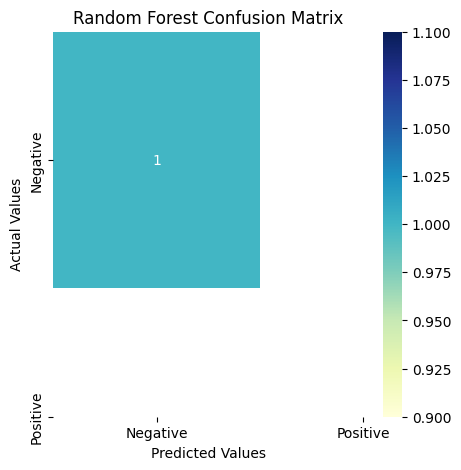

In [72]:
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(cm)
plt.figure(figsize=(5, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="YlGnBu", xticklabels=["Negative", "Positive"], yticklabels=["Negative", "Positive"])
plt.xlabel("Predicted Values")
plt.ylabel("Actual Values")
plt.title("Random Forest Confusion Matrix")
plt.show()

In [73]:
best_accuracy = 0
n_estimators_val = 5

print("Testing different n_estimators values...\n")

for i in np.arange(1, 30, 2):
    temp_model = RandomForestClassifier(n_estimators=i, random_state=42)
    temp_model.fit(X_train, y_train)
    temp_pred = temp_model.predict(X_test)
    score = accuracy_score(y_test, temp_pred)
    print(f"n_estimators = {i}, Accuracy = {round(score * 100, 2)}%")
    if score > best_accuracy:
        best_accuracy = score
        n_estimators_val = i

print(f"Best accuracy: {round(best_accuracy * 100, 2)}% with n_estimators = {n_estimators_val}")

Testing different n_estimators values...

n_estimators = 1, Accuracy = 0.0%
n_estimators = 3, Accuracy = 0.0%
n_estimators = 5, Accuracy = 0.0%
n_estimators = 7, Accuracy = 0.0%
n_estimators = 9, Accuracy = 0.0%
n_estimators = 11, Accuracy = 0.0%
n_estimators = 13, Accuracy = 0.0%
n_estimators = 15, Accuracy = 100.0%
n_estimators = 17, Accuracy = 100.0%
n_estimators = 19, Accuracy = 100.0%
n_estimators = 21, Accuracy = 100.0%
n_estimators = 23, Accuracy = 100.0%
n_estimators = 25, Accuracy = 100.0%
n_estimators = 27, Accuracy = 100.0%
n_estimators = 29, Accuracy = 100.0%
Best accuracy: 100.0% with n_estimators = 15


In [74]:
model = RandomForestClassifier( n_estimators=n_estimators_val, random_state=42 )
model.fit(X_train, y_train)
print("Optimized Random Forest Model:")
print(model)

Optimized Random Forest Model:
RandomForestClassifier(n_estimators=np.int64(15), random_state=42)


In [75]:
def predict_sentiment(sample_review):
    review = re.sub("[^a-zA-Z]", " ", sample_review).lower()
    words = review.split()
    words = [w for w in words if w not in english_stopwords]
    words = [ps.stem(w) for w in words]
    review = " ".join(words)
    data = cv.transform([review]).toarray()
    return model.predict(data)[0]

sample_review = "The food is really good here."
prediction = predict_sentiment(sample_review)
print("Review:", sample_review)
if prediction == 1:
    print("This is a POSITIVE review.")
else:
    print("This is a NEGATIVE review!")

Review: The food is really good here.
This is a NEGATIVE review!


In [76]:
sample_review = ( "The food was absolutely awful." )
prediction = predict_sentiment(sample_review)
print("Review:", sample_review)
if prediction == 1:
    print("This is a POSITIVE review.")
else:
    print("This is a NEGATIVE review!")

Review: The food was absolutely awful.
This is a NEGATIVE review!


In [77]:
final_predictions = model.predict(X_test)
accuracy = accuracy_score(y_test, final_predictions)
precision = precision_score(y_test, final_predictions, zero_division=0)
recall = recall_score(y_test, final_predictions, zero_division=0)
print("\n==========================================")
print(" FINAL RANDOM FOREST MODEL PERFORMANCE")
print("==========================================")
print("Accuracy :", round(accuracy * 100, 2), "%")
print("Precision:", round(precision, 2))
print("Recall   :", round(recall, 2))
print("Best n_estimators:", n_estimators_val)


 FINAL RANDOM FOREST MODEL PERFORMANCE
Accuracy : 100.0 %
Precision: 1.0
Recall   : 1.0
Best n_estimators: 15
